In [ ]:
# Fix protobuf incompatibility and add helpful deps
%pip -q install "protobuf<5" tensorflow-datasets==4.9.6 pydot graphviz

# Auto-restart the Colab runtime so the new libs are picked up
import os, sys
print("Installed. Restarting runtime to apply changes...")
os.kill(os.getpid(), 9)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 28.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colabsqlviz 0.2.5 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.
grpcio-status 1.75.1 requires protobuf<7.0.0,>=6.31.1, but you have protobuf 4.25.8 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.


In [ ]:
# === Environment re-check after restart ===
import os, sys, platform, datetime, random, numpy as np
import tensorflow as tf

print("Python:", sys.version)
print("Platform:", platform.platform())
print("TensorFlow:", tf.__version__)

print("Physical devices:")
for dev_type in ["CPU", "GPU", "TPU"]:
    devs = tf.config.list_physical_devices(dev_type)
    print(f"  {dev_type}: {len(devs)} -> {devs}")

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

RUN_TS = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
BASE_DIR = f"cifar10_run_{RUN_TS}"
LOG_DIR  = os.path.join(BASE_DIR, "logs")
ART_DIR  = os.path.join(BASE_DIR, "artifacts")
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(ART_DIR, exist_ok=True)
print("Working dirs:")
print(" ", BASE_DIR)
print(" ", LOG_DIR)
print(" ", ART_DIR)

# quick sanity
a = tf.constant([1.0, 2.0, 3.0]); b = tf.constant([3.0, 2.0, 1.0])
print("Sanity (a+b):", (a+b).numpy())


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow: 2.19.0
Physical devices:
  CPU: 1 -> [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
  GPU: 0 -> []
  TPU: 0 -> []
Working dirs:
  cifar10_run_20251109-133507
  cifar10_run_20251109-133507/logs
  cifar10_run_20251109-133507/artifacts
Sanity (a+b): [4. 4. 4.]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step
Train: (50000, 32, 32, 3) (50000, 1)
Test : (10000, 32, 32, 3) (10000, 1)
Unique classes in train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


/tmp/ipython-input-147138548.py:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(labels[j])], fontsize=9)


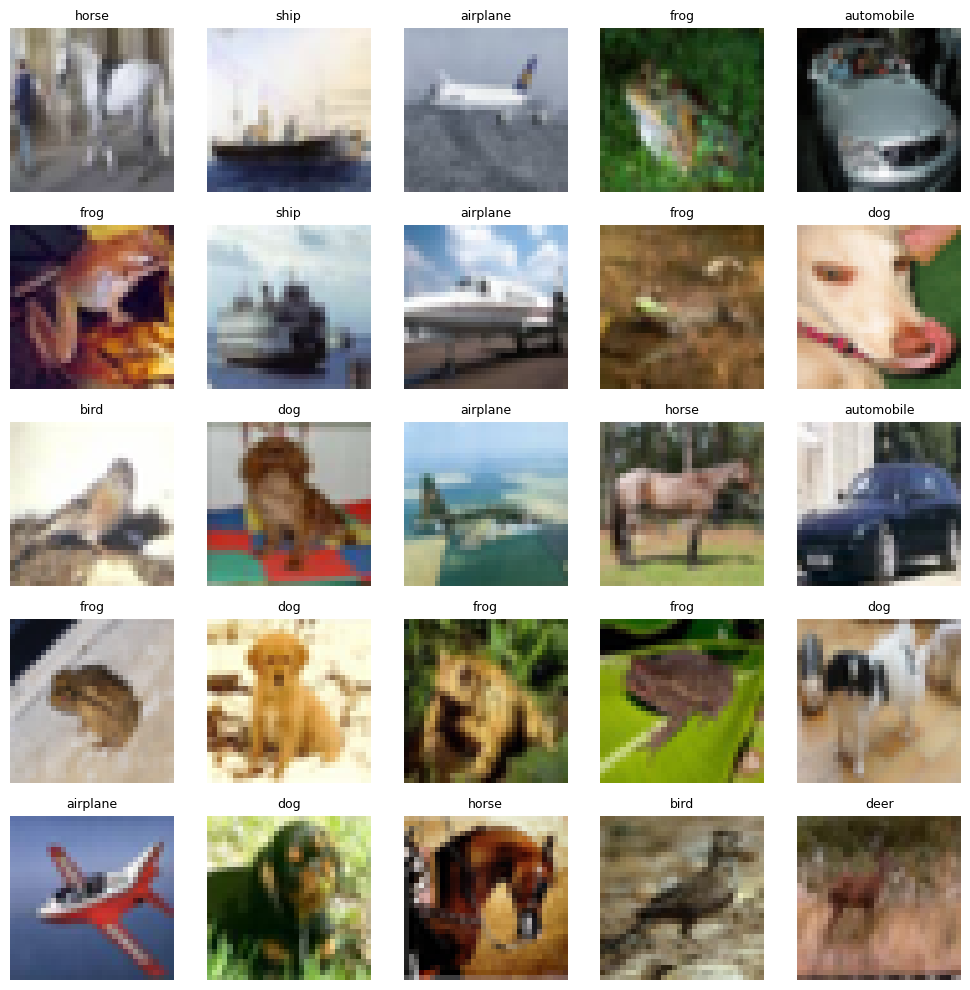

In [ ]:
# === Load CIFAR-10 and quick EDA/visualization ===
# Using Keras built-in dataset for simplicity and reliability.

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# 1) Load data
# x: uint8 images in [0,255], shape (N, 32, 32, 3)
# y: class indices in [0..9], shape (N, 1)
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 2) Basic shapes and stats
print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape,  y_test.shape)
unique_classes = np.unique(y_train)
print("Unique classes in train:", unique_classes.ravel().tolist())

# 3) Class names per CIFAR-10 convention
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
print("Class names:", class_names)

# 4) Show a 5x5 grid of sample images with labels
def show_grid(images, labels, n_rows=5, n_cols=5):
    plt.figure(figsize=(10,10))
    idx = np.random.choice(len(images), n_rows*n_cols, replace=False)
    for i, j in enumerate(idx):
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(images[j])
        # labels are shape (1,), take int
        plt.title(class_names[int(labels[j])], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_grid(x_train, y_train, 5, 5)


In [ ]:
# === Build efficient tf.data pipelines for CIFAR-10 ===
import tensorflow as tf
import numpy as np

AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 64
VAL_FRACTION = 0.1  # 10% of train -> validation

# 1) Fix label shape for safer indexing (avoids NumPy deprecation warnings)
#    y_* come as shape (N,1); we squeeze to (N,)
y_train_flat = y_train.squeeze().astype(np.int64)
y_test_flat  = y_test.squeeze().astype(np.int64)

# 2) Split train into train/val
num_train = x_train.shape[0]
num_val   = int(num_train * VAL_FRACTION)
idx = np.random.permutation(num_train)
val_idx   = idx[:num_val]
train_idx = idx[num_val:]

x_tr, y_tr = x_train[train_idx], y_train_flat[train_idx]
x_val, y_val = x_train[val_idx], y_train_flat[val_idx]

print("Train split:", x_tr.shape, y_tr.shape)
print("Val split  :", x_val.shape, y_val.shape)
print("Test       :", x_test.shape, y_test_flat.shape)

# 3) Normalization function: map uint8 [0,255] -> float32 [0,1]
def normalize_images(img, label):
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.int32)

# 4) Build tf.data datasets
ds_train = (
    tf.data.Dataset.from_tensor_slices((x_tr, y_tr))
    .shuffle(buffer_size=len(x_tr), reshuffle_each_iteration=True)
    .map(normalize_images, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

ds_val = (
    tf.data.Dataset.from_tensor_slices((x_val, y_val))
    .map(normalize_images, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

ds_test = (
    tf.data.Dataset.from_tensor_slices((x_test, y_test_flat))
    .map(normalize_images, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .cache()
    .prefetch(AUTOTUNE)
)

# 5) Peek at one batch to verify shapes and ranges
xb, yb = next(iter(ds_train))
print("One batch images:", xb.shape, xb.dtype, "range:", (tf.reduce_min(xb).numpy(), tf.reduce_max(xb).numpy()))
print("One batch labels:", yb.shape, yb.dtype, "min/max:", (tf.reduce_min(yb).numpy(), tf.reduce_max(yb).numpy()))


Train split: (45000, 32, 32, 3) (45000,)
Val split  : (5000, 32, 32, 3) (5000,)
Test       : (10000, 32, 32, 3) (10000,)
One batch images: (64, 32, 32, 3) <dtype: 'float32'> range: (np.float32(0.0), np.float32(1.0))
One batch labels: (64,) <dtype: 'int32'> min/max: (np.int32(0), np.int32(9))


In [ ]:
# === Define a strong CNN baseline for CIFAR-10 + visualize the architecture ===
# Notes:
# - Data augmentation is inside the model for simplicity/reproducibility.
# - BatchNorm after Conv, Dropout after each block to regularize.
# - 'sparse_categorical_crossentropy' fits integer labels 0..9.

import os
import tensorflow as tf
from tensorflow.keras import layers, models

INPUT_SHAPE = (32, 32, 3)
NUM_CLASSES = 10

# 1) Data augmentation pipeline (light but useful)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")

# 2) CNN backbone
def build_cifar10_cnn():
    inputs = layers.Input(shape=INPUT_SHAPE)
    x = data_augmentation(inputs)

    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = models.Model(inputs, outputs, name="cifar10_cnn_baseline")
    return model

model = build_cifar10_cnn()

# 3) Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(),  # default LR=1e-3 is fine for baseline
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 4) Summary
model.summary()

# 5) Save a PNG diagram of the model
png_path = os.path.join(ART_DIR, "cifar10_cnn.png")
tf.keras.utils.plot_model(model, to_file=png_path, show_shapes=True, expand_nested=True)
print("Model diagram saved to:", png_path)


Model: "cifar10_cnn_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,456 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 815,466 (3.11 MB)

 Trainable params: 814,570 (3.11 MB)

 Non-trainable params: 896 (3.50 KB)

Model diagram saved to: cifar10_run_20251109-133507/artifacts/cifar10_cnn.png


In [ ]:
# === Train the model with useful callbacks ===
# Tips:
# - On CPU, start with fewer epochs to validate the pipeline quickly.
# - We use EarlyStopping to stop when val_loss stops improving.
# - ModelCheckpoint saves the best weights by val_accuracy.

import os, datetime
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

EPOCHS = 12            # start modest; we can extend later
PATIENCE = 3           # early stop patience
RUN_TAG = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# 1) Prepare callbacks
tb_log_dir = os.path.join(LOG_DIR, f"tb_{RUN_TAG}")
os.makedirs(tb_log_dir, exist_ok=True)

ckpt_path = os.path.join(ART_DIR, f"cifar10_cnn_best_{RUN_TAG}.weights.h5")

callbacks = [
    TensorBoard(log_dir=tb_log_dir, histogram_freq=0),  # set histogram_freq>0 if you want layer histograms
    EarlyStopping(monitor="val_loss", mode="min", patience=PATIENCE, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=ckpt_path, monitor="val_accuracy", mode="max",
                    save_best_only=True, save_weights_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

# 2) Fit
history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\nBest weights checkpoint (by val_accuracy):", ckpt_path)
print("TensorBoard logs:", tb_log_dir)


Epoch 1/12
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.2699 - loss: 2.0583
Epoch 1: val_accuracy improved from -inf to 0.46480, saving model to cifar10_run_20251109-133507/artifacts/cifar10_cnn_best_20251109-133916.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 188s 258ms/step - accuracy: 0.2700 - loss: 2.0576 - val_accuracy: 0.4648 - val_loss: 1.4637 - learning_rate: 0.0010
Epoch 2/12
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.4236 - loss: 1.5558
Epoch 2: val_accuracy improved from 0.46480 to 0.50700, saving model to cifar10_run_20251109-133507/artifacts/cifar10_cnn_best_20251109-133916.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 181s 257ms/step - accuracy: 0.4236 - loss: 1.5556 - val_accuracy: 0.5070 - val_loss: 1.3371 - learning_rate: 0.0010
Epoch 3/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.4871 - loss: 1.4080
Epoch 3: val_accuracy improved from 0.50700 to 0.59780, saving model to cifar10_run_20251109-133507/artifacts/cifar10_cnn_best_20251109-13391

[Keras] Test loss: 0.7535  |  Test accuracy: 0.7510
[Manual] Test accuracy: 0.751

Classification report:

              precision    recall  f1-score   support

    airplane     0.7972    0.7940    0.7956      1000
  automobile     0.9253    0.8670    0.8952      1000
        bird     0.7315    0.5830    0.6489      1000
         cat     0.6606    0.4690    0.5485      1000
        deer     0.6795    0.7590    0.7171      1000
         dog     0.7969    0.5060    0.6190      1000
        frog     0.5911    0.9470    0.7279      1000
       horse     0.7902    0.8060    0.7980      1000
        ship     0.9275    0.8440    0.8838      1000
       truck     0.7328    0.9350    0.8216      1000

    accuracy                         0.7510     10000
   macro avg     0.7632    0.7510    0.7456     10000
weighted avg     0.7632    0.7510    0.7456     10000



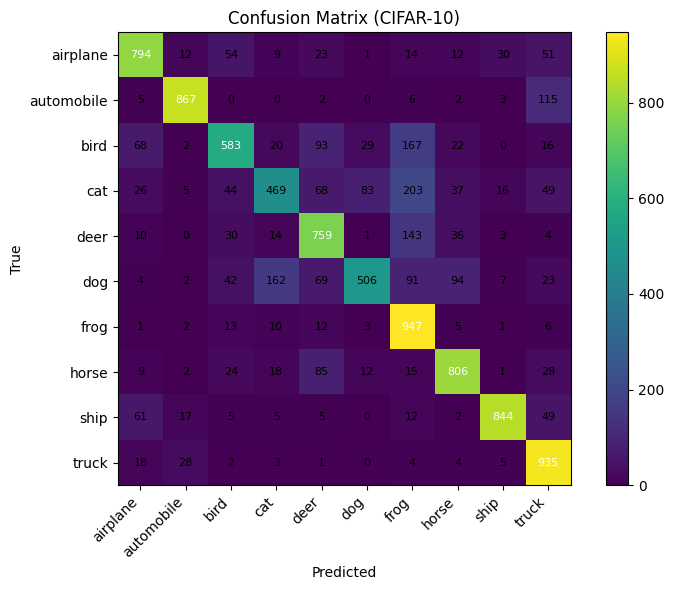

In [ ]:
# === Evaluate on test set and analyze errors (fixed) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1) Quick test evaluation from Keras
test_loss, test_acc = model.evaluate(ds_test, verbose=0)
print(f"[Keras] Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

# 2) Predict class probabilities -> class indices
y_prob = model.predict(ds_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# 3) Ground truth labels + manual accuracy (fixed rounding)
manual_acc = accuracy_score(y_test_flat, y_pred)
print("[Manual] Test accuracy:", round(manual_acc, 4))

# 4) Classification report per class
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]
print("\nClassification report:\n")
print(classification_report(y_test_flat, y_pred, target_names=class_names, digits=4))

# 5) Confusion matrix
cm = confusion_matrix(y_test_flat, y_pred, labels=range(10))
fig = plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix (CIFAR-10)")
plt.colorbar()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)
plt.xlabel("Predicted")
plt.ylabel("True")

# annotate cells
th = cm.max() * 0.6
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        val = cm[i, j]
        color = "white" if val > th else "black"
        plt.text(j, i, str(val), ha="center", va="center", color=color, fontsize=8)

plt.tight_layout()
plt.show()


Misclassified: 2490 of 10000


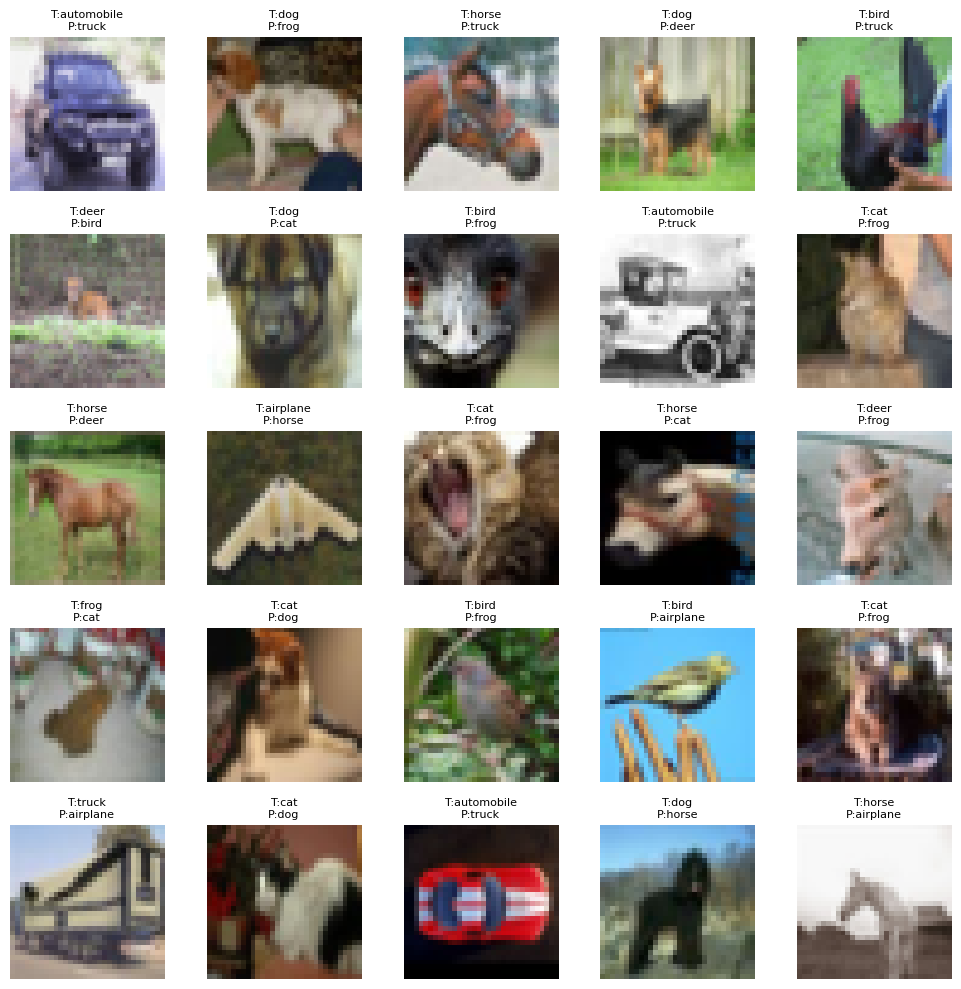

In [ ]:
# === Visualize misclassified examples ===
import numpy as np
import matplotlib.pyplot as plt

# Reuse class names
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

# 1) Collect misclassified indices
mis_idx = np.where(y_pred != y_test_flat)[0]
print(f"Misclassified: {len(mis_idx)} of {len(y_test_flat)}")

# 2) Show a grid of the first 25 mistakes
N = min(25, len(mis_idx))
sel = mis_idx[:N]

plt.figure(figsize=(10,10))
for i, k in enumerate(sel):
    plt.subplot(5,5,i+1)
    plt.imshow(x_test[k])
    true_lbl = class_names[int(y_test_flat[k])]
    pred_lbl = class_names[int(y_pred[k])]
    plt.title(f"T:{true_lbl}\nP:{pred_lbl}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# === Save/export model artifacts (Keras 3 compatible) ===
# Notes:
# - Use `model.export(dir)` to create a TensorFlow SavedModel (for TF Serving / TFLite).
# - Use `model.save("name.keras")` for the native Keras format (recommended for reloading in code).
# - We also save weights as H5 for convenience.

import os, json
from pathlib import Path

# Ensure dirs exist
os.makedirs(ART_DIR, exist_ok=True)

# 1) Export a TensorFlow SavedModel (directory)
saved_model_dir = os.path.join(ART_DIR, "saved_model")  # directory path is OK for export()
model.export(saved_model_dir)
print("SavedModel (export) ->", saved_model_dir)

# 2) Save native Keras model (.keras) — recommended for reloading in Python
keras_path = os.path.join(ART_DIR, "cifar10_cnn.keras")
model.save(keras_path)
print("Keras model ->", keras_path)

# 3) Save weights explicitly as H5
weights_path = os.path.join(ART_DIR, "cifar10_cnn_final.weights.h5")
model.save_weights(weights_path)
print("Weights ->", weights_path)

# 4) Save a JSON with run metadata
meta = {
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "batch_size": 64,
    "val_fraction": 0.1,
    "model_name": model.name,
    "input_shape": list(model.input_shape[1:]),
    "ts_dirs": {"BASE_DIR": BASE_DIR, "LOG_DIR": LOG_DIR, "ART_DIR": ART_DIR}
}
meta_path = os.path.join(ART_DIR, "run_metadata.json")
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)
print("Run metadata ->", meta_path)

# 5) Re-print TB path for convenience
print("TensorBoard logs:", tb_log_dir)
print("Tip: run `tensorboard --logdir", tb_log_dir, "` to view curves.")


Saved artifact at 'cifar10_run_20251109-133507/artifacts/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  136226981127440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014534224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014544016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014534032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014546896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014547088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014545936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014544592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014547280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136224014548432: TensorSpec(shape=(), dtype=tf.resou

In [ ]:
# === Fine-tuning (fixed): AdamW + CosineDecay, no ReduceLROnPlateau ===
import os, math, datetime, tensorflow as tf
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ModelCheckpoint

# 0) Reload best weights again (safety)
best_ckpt = sorted([p for p in os.listdir(ART_DIR) if p.startswith("cifar10_cnn_best_") and p.endswith(".weights.h5")])
if best_ckpt:
    best_path = os.path.join(ART_DIR, best_ckpt[-1])
    model.load_weights(best_path)
    print("Loaded best weights:", best_path)

# 1) Steps & schedule
EPOCHS_FT = 12  # a few more epochs
card = tf.data.experimental.cardinality(ds_train).numpy()
steps_per_epoch = int(card)
total_steps = EPOCHS_FT * steps_per_epoch
print("steps_per_epoch:", steps_per_epoch, "total_steps:", total_steps)

lr_schedule = CosineDecay(initial_learning_rate=1e-3, decay_steps=total_steps)

# 2) Optimizer with weight decay
optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-4)

# 3) Re-compile
model.compile(optimizer=optimizer,
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# 4) Callbacks (no ReduceLROnPlateau)
RUN_TAG = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tb_log_dir_ft = os.path.join(LOG_DIR, f"tb_tune_{RUN_TAG}")
os.makedirs(tb_log_dir_ft, exist_ok=True)

ckpt_path_ft = os.path.join(ART_DIR, f"cifar10_cnn_tuned_{RUN_TAG}.weights.h5")
callbacks_ft = [
    TensorBoard(log_dir=tb_log_dir_ft),
    EarlyStopping(monitor="val_loss", mode="min", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint(filepath=ckpt_path_ft, monitor="val_accuracy", mode="max",
                    save_best_only=True, save_weights_only=True, verbose=1),
]

# 5) Train
history_ft = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS_FT,
    callbacks=callbacks_ft,
    verbose=1
)

# 6) Evaluate on test
test_loss_ft, test_acc_ft = model.evaluate(ds_test, verbose=0)
print(f"[Fine-tuned] Test loss: {test_loss_ft:.4f} | Test accuracy: {test_acc_ft:.4f}")
print("Best tuned weights:", ckpt_path_ft)
print("TensorBoard (tuning):", tb_log_dir_ft)


Loaded best weights: cifar10_run_20251109-133507/artifacts/cifar10_cnn_best_20251109-133916.weights.h5
steps_per_epoch: 704 total_steps: 8448
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 45 variables whereas the saved optimizer has 46 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.7159 - loss: 0.8412
Epoch 1: val_accuracy improved from -inf to 0.73920, saving model to cifar10_run_20251109-133507/artifacts/cifar10_cnn_tuned_20251109-144058.weights.h5
704/704 ━━━━━━━━━━━━━━━━━━━━ 188s 258ms/step - accuracy: 0.7160 - loss: 0.8412 - val_accuracy: 0.7392 - val_loss: 0.7735
Epoch 2/12
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.7263 - loss: 0.8124
Epoch 2: val_accuracy did not improve from 0.73920
704/704 ━━━━━━━━━━━━━━━━━━━━ 182s 258ms/step - accuracy: 0.7264 - loss: 0.8123 - val_accuracy: 0.7346 - val_loss: 0.7739
Epoch 3/12
703/704 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.7359 - loss: 0.7890
Epoch 3: val_accuracy did not improve from 0.73920
704/704 ━━━━━━━━━━━━━━━━━━━━ 200s 256ms/step - accuracy: 0.7359 - loss: 0.7889 - val_accuracy: 0.6886 - val_loss: 0.9231
Epoch 4/12
704/704 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.7581 - loss: 0.7345
Epoch 4: val_accuracy improved from 0.7392